### 0. 데이터 로딩
- CSV 파일을 불러와서 분석에 사용할 Actor(cluster_sbert) 기준으로 데이터 준비

In [4]:
import pandas as pd
import ast

# CSV 파일 경로를 지정하세요
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/03_Apartment_Options_merged.csv_document.csv"  # ← 실제 파일 경로로 변경

df = pd.read_csv(CSV_PATH)
df.head()

,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","['자유', '다방', '신축', '아파트', '옵션', '신축', '아파트', '...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"['자유', '게시판', '아파트', '옵션', '확인', '주변', '정도', '...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"['자유', '게시판', '아파트', '에어컨', '옵션', '관련', '안녕', ...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"['자유', '게시판', '아파트', '옵션', '중도', '대출', '옵션', '...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"['고민', '상담', '신축', '아파트', '조명', '옵션', '안녕', '청...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# tokens 컬럼이 문자열로 저장된 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

print("데이터 shape:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head()

데이터 shape: (57358, 5)
컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster_sbert']


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1


In [6]:
# Actor(cluster_sbert) 기준 군집 수 확인
print("cluster_sbert 군집별 문서 수:")
print(df['cluster_sbert'].value_counts().sort_index())

cluster_sbert 군집별 문서 수:
cluster_sbert
0    19445
1    18118
2    19618
3      177
Name: count, dtype: int64


### 1. LDA를 위한 데이터 전처리
- 특정 Actor(cluster_sbert)를 선택하여 단어사전 생성 및 BOW 변환

In [7]:
# 분석할 Actor 번호 설정 (cluster_sbert 값 중 하나)
TARGET_ACTOR = 1  # ← 분석할 Actor 번호로 변경

df_actor = df[df['cluster_sbert'] == TARGET_ACTOR].copy()
print(f"Actor {TARGET_ACTOR} 문서 수:", df_actor.shape[0])
df_actor.head()

Actor 1 문서 수: 18118


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1


In [9]:
# 처음 실행 시 주석 해제
!pip install kiwipiepy umap-learn scikit-learn gensim matplotlib pandas tqdm
!pip install sentence-transformers

In [10]:
from gensim.corpora import Dictionary

# tokens 컬럼을 리스트로 변환
all_documents = list(df_actor['tokens'])

# 단어사전 구축
word_dict = Dictionary(all_documents)
print("단어사전 크기:", len(word_dict))
print("샘플 토큰:", list(word_dict.token2id.items())[:10])

단어사전 크기: 18633
샘플 토큰: [('감각', 0), ('고르', 1), ('고민', 2), ('꾸미', 3), ('나중', 4), ('다방', 5), ('다운', 6), ('두르', 7), ('드리', 8), ('라이트', 9)]


In [11]:
# 전체 문서에 BOW 변환
corpus = [word_dict.doc2bow(doc) for doc in all_documents]

# 샘플 확인
print("원문 토큰:", all_documents[0])
print("BOW 변환:", corpus[0])

원문 토큰: ['자유', '다방', '신축', '아파트', '옵션', '신축', '아파트', '옵션', '고르', '시스템', '에어컨', '바닥', '생각', '고민', '조명', '특화', '마음', '시공', '정도', '우물천장', '라인', '두르', '색상', '조절', '색상', '조정', '식탁', '주방', '복도', '다운', '라이트', '비싸', '나중', '입주', '업체', '알아보', '인테리어', '모르', '꾸미', '감각', '조언', '부탁', '드리']
BOW 변환: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 2), (18, 1), (19, 1), (20, 1), (21, 1), (22, 2), (23, 2), (24, 1), (25, 1), (26, 1), (27, 2), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1)]


### 2. 토픽 수 선정
- perplexity와 coherence를 비교하여 최적 토픽 수 결정

In [12]:
!pip install new_value_analysis -q

  0%|          | 0/8 [00:00<?, ?it/s]

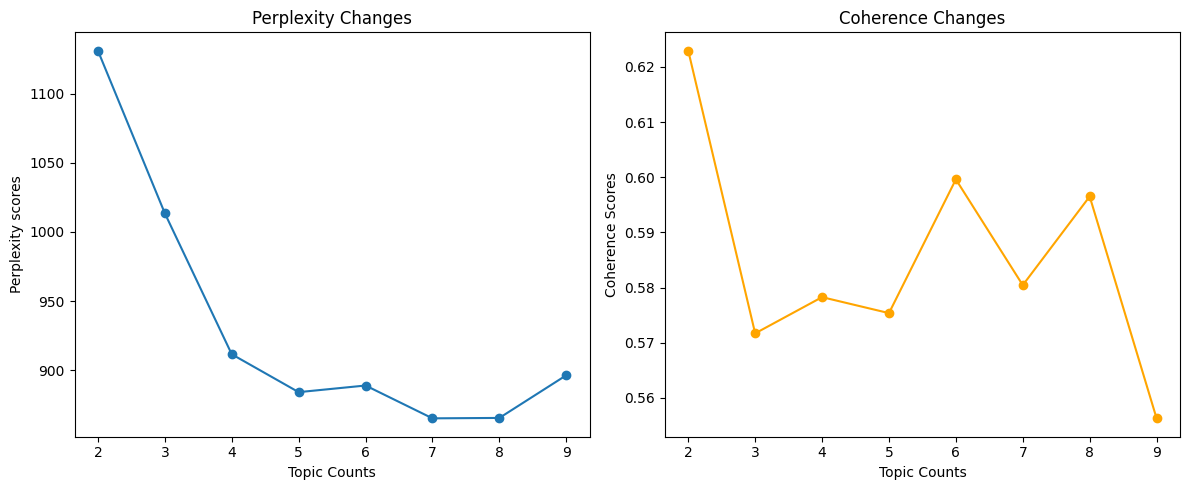

In [13]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

lda_perplexity_coherence_plot(
    corpus=corpus,
    word_dict=word_dict,
    all_documents=all_documents,
    topic_range=range(2, 10),   # 2~9개 토픽 수 비교
    passes=10,
    iterations=20,
    random_state=2026,
    fixed_topn=10,
    figsize=(12, 5)
)
# perplexity 낮을수록 좋고, coherence 높을수록 좋음
# 그래프를 보고 아래 TOPIC_NUM을 결정하세요

### 3. LDA 모델 학습 및 Action 번호 매칭

In [14]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import gensim

TOPIC_NUM = 4  # ← 위 그래프를 보고 결정한 토픽 수로 변경

ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    id2word=word_dict,
    num_topics=TOPIC_NUM,
    passes=10,
    iterations=20,
    random_state=2026
)

# 토픽별 주요 단어 확인
ldamodel.print_topics(num_words=10)

[(0,
  '0.094*"옵션" + 0.034*"아파트" + 0.028*"선택" + 0.027*"에어컨" + 0.027*"입주" + 0.019*"시스템" + 0.018*"고민" + 0.017*"신축" + 0.017*"자유" + 0.013*"게시판"'),
 (1,
  '0.070*"청소" + 0.062*"입주" + 0.026*"업체" + 0.022*"이사" + 0.014*"추가" + 0.013*"비용" + 0.012*"견적" + 0.011*"확인" + 0.011*"상담" + 0.010*"따르"'),
 (2,
  '0.018*"인테리어" + 0.018*"시공" + 0.013*"공사" + 0.011*"타일" + 0.010*"마이너스" + 0.009*"주방" + 0.009*"업체" + 0.008*"설치" + 0.007*"옵션" + 0.007*"공간"'),
 (3,
  '0.017*"대출" + 0.014*"분양" + 0.010*"아파트" + 0.008*"월세" + 0.008*"옵션" + 0.008*"가능" + 0.007*"정보" + 0.007*"주택" + 0.006*"전세" + 0.006*"허용"')]

In [15]:
from new_value_analysis.action_finder import assign_action_number

action_number_assignment = assign_action_number(ldamodel, corpus=corpus)
print("Action 번호 할당 결과 샘플:", action_number_assignment[:10])

Action 번호 할당 결과 샘플: [0, 0, 0, 0, 0, 2, 0, 0, 3, 0]


In [16]:
print(f"데이터프레임 행 수: {len(df_actor)}")
print(f"새 데이터 리스트 수: {len(action_number_assignment)}")
print(f"차이: {len(df_actor) - len(action_number_assignment)}개 부족")

데이터프레임 행 수: 18118
새 데이터 리스트 수: 18118
차이: 0개 부족


In [17]:
# action 번호를 새로운 컬럼으로 추가
df_actor = df_actor.copy()
df_actor['action_cluster'] = action_number_assignment

print("Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())
df_actor.head()

Action별 문서 수:
action_cluster
0    11804
1      999
2     3249
3     2066
Name: count, dtype: int64


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1,0
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1,0
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1,0
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1,0
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1,0


### 4. pyLDAvis 시각화

In [18]:
!pip install pyldavis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.0 MB/s eta 0:00:00


In [19]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

prepared_data = gensimvis.prepare(ldamodel, corpus, word_dict)
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
# HTML로 저장
pyLDAvis.save_html(prepared_data, f"./ldavis_actor{TARGET_ACTOR}_action.html")
print(f"저장 완료: ldavis_actor{TARGET_ACTOR}_action.html")

저장 완료: ldavis_actor1_action.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 5. pyLDAvis 기준으로 Action 번호 재매핑
- LDA 모델의 토픽 인덱스와 pyLDAvis의 토픽 인덱스가 불일치할 수 있음
- 아래 매핑을 pyLDAvis 시각화 결과를 보고 직접 수정하세요

In [21]:
# LDA 토픽 번호 확인
print("LDA 토픽 번호 및 주요 단어:")
ldamodel.print_topics(num_words=10)

LDA 토픽 번호 및 주요 단어:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[(0,
  '0.094*"옵션" + 0.034*"아파트" + 0.028*"선택" + 0.027*"에어컨" + 0.027*"입주" + 0.019*"시스템" + 0.018*"고민" + 0.017*"신축" + 0.017*"자유" + 0.013*"게시판"'),
 (1,
  '0.070*"청소" + 0.062*"입주" + 0.026*"업체" + 0.022*"이사" + 0.014*"추가" + 0.013*"비용" + 0.012*"견적" + 0.011*"확인" + 0.011*"상담" + 0.010*"따르"'),
 (2,
  '0.018*"인테리어" + 0.018*"시공" + 0.013*"공사" + 0.011*"타일" + 0.010*"마이너스" + 0.009*"주방" + 0.009*"업체" + 0.008*"설치" + 0.007*"옵션" + 0.007*"공간"'),
 (3,
  '0.017*"대출" + 0.014*"분양" + 0.010*"아파트" + 0.008*"월세" + 0.008*"옵션" + 0.008*"가능" + 0.007*"정보" + 0.007*"주택" + 0.006*"전세" + 0.006*"허용"')]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
# ↓ pyLDAvis 시각화 결과를 보고 매핑 딕셔너리를 직접 수정하세요
# 예시: LDA 토픽 0 → pyLDAvis 토픽 2, LDA 토픽 1 → pyLDAvis 토픽 3, ...
topic_mapping = {
    0: 2,
    1: 4,
    2: 1,
    3: 3,
}

df_actor['action_cluster'] = df_actor['action_cluster'].map(topic_mapping)

print("재매핑 후 Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

재매핑 후 Action별 문서 수:
action_cluster
1     3249
2    11804
3     2066
4      999
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# 결과 저장 (pickle)
SAVE_PATH = f"./cluster_df_{TARGET_ACTOR}_action.pkl"
df_actor.to_pickle(SAVE_PATH)
print(f"저장 완료: {SAVE_PATH}")
df_actor.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

OSError: Cannot save file into a non-existent directory: 'data'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag